In [4]:
!git clone https://github.com/MisbahKhan0009/Dehazing.git

Cloning into 'Dehazing'...
remote: Enumerating objects: 7176, done.
remote: Counting objects: 100% (286/286), done.
remote: Compressing objects: 100% (238/238), done.
remote: Total 7176 (delta 61), reused 265 (delta 41), pack-reused 6890 (from 2)
Receiving objects: 100% (7176/7176), 171.00 MiB | 36.05 MiB/s, done.
Resolving deltas: 100% (61/61), done.


In [5]:
# Install required packages if missing (safe to re-run).
import sys, subprocess

# Map import names to pip install names when they differ
PIP_NAME = {
    'cv2': 'opencv-python',
    'skimage': 'scikit-image',
}

def ensure(import_name):
    try:
        __import__(import_name)
        return True
    except Exception:
        pkg = PIP_NAME.get(import_name, import_name)
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
            __import__(import_name)
            return True
        except Exception as e:
            print(f'Failed to install {import_name} (pip: {pkg}):', e)
            return False

# Core deps
ok = True
for p in ['torch', 'numpy', 'tqdm', 'cv2', 'skimage', 'matplotlib']:
    ok = ensure(p) and ok

if not ok:
    print('Some packages failed to install. You may need to restart the kernel or install manually.')
else:
    print('All required packages are available.')

All required packages are available.


In [6]:
# Imports and device setup
import os
import csv
import math
import random
from glob import glob

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import cv2
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [8]:
# Config
from dataclasses import dataclass

@dataclass
class Config:
    dataset_root: str = r"/content/Dehazing/Dataset"
    noisy_dir: str = os.path.join(dataset_root, 'noisy')
    clean_dir: str = os.path.join(dataset_root, 'clean')
    mapping_csv: str = os.path.join(dataset_root, 'dataset_mapping.csv')

    out_dir: str = os.path.join('checkpoints', 'unet_dehazing')
    vis_dir: str = os.path.join('Dataset', 'visualizations', 'unet_results')

    image_size: int = 256      # must be divisible by 32 for U-Net depth=5
    in_channels: int = 1       # using grayscale by default
    out_channels: int = 1
    bilinear: bool = True

    batch_size: int = 8
    num_workers: int = 0       # set >0 if your environment supports it
    epochs: int = 20
    lr: float = 2e-4
    weight_decay: float = 0.0

    val_split: float = 0.1
    seed: int = 42

cfg = Config()

# Resolve dataset_root relative to the notebook location if needed
def resolve_dataset_paths(c):
    if os.path.isabs(c.dataset_root) and os.path.isdir(c.dataset_root):
        root = c.dataset_root
    else:
        candidates = [
            c.dataset_root,
            os.path.join('..', 'Dataset'),
            os.path.join('..', '..', 'Dataset'),
        ]
        root = None
        for cand in candidates:
            if os.path.isdir(cand):
                root = os.path.abspath(cand)
                break
        if root is None:
            # Fallback to initial value (may be non-existent; later code will show diagnostics)
            root = os.path.abspath(c.dataset_root)
    # Update cfg with absolute, consistent paths
    c.dataset_root = root
    c.noisy_dir = os.path.join(root, 'noisy')
    c.clean_dir = os.path.join(root, 'clean')
    c.mapping_csv = os.path.join(root, 'dataset_mapping.csv')
    # Put visualizations under the resolved dataset root for clarity
    c.vis_dir = os.path.join(root, 'visualizations', 'unet_results')
    return c

cfg = resolve_dataset_paths(cfg)
print('Resolved dataset root to:', cfg.dataset_root)
cfg

Resolved dataset root to: /content/Dehazing/Dataset


Config(dataset_root='/content/Dehazing/Dataset', noisy_dir='/content/Dehazing/Dataset/noisy', clean_dir='/content/Dehazing/Dataset/clean', mapping_csv='/content/Dehazing/Dataset/dataset_mapping.csv', out_dir='checkpoints/unet_dehazing', vis_dir='/content/Dehazing/Dataset/visualizations/unet_results', image_size=256, in_channels=1, out_channels=1, bilinear=True, batch_size=8, num_workers=0, epochs=20, lr=0.0002, weight_decay=0.0, val_split=0.1, seed=42)

In [9]:
# Utils: seeding, dirs, metrics
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def tensor_to_img(t: torch.Tensor):
    # expects shape (1,H,W) or (H,W) in [0,1]
    t = t.detach().cpu().float()
    if t.ndim == 3 and t.size(0) == 1:
        t = t[0]
    arr = t.numpy()
    arr = np.clip(arr, 0, 1)
    return arr

def compute_psnr_ssim_batch(pred: torch.Tensor, target: torch.Tensor):
    # pred/target in [0,1], shape (B,1,H,W)
    pred = pred.detach().cpu().float()
    target = target.detach().cpu().float()
    B = pred.size(0)
    psnrs, ssims = [], []
    for i in range(B):
        p = pred[i,0].numpy()
        g = target[i,0].numpy()
        psnrs.append(peak_signal_noise_ratio(g, p, data_range=1.0))
        try:
            ssim = structural_similarity(g, p, data_range=1.0)
        except TypeError:
            # Older skimage requires win_size odd and smaller than image
            ssim = structural_similarity(g, p)
        ssims.append(ssim)
    return float(np.mean(psnrs)), float(np.mean(ssims))

set_seed(cfg.seed)
ensure_dir(cfg.out_dir)
ensure_dir(cfg.vis_dir)
print('Setup complete.')

Setup complete.


In [10]:
# Dataset
class PairedUltrasoundDataset(Dataset):
    def __init__(self, pairs, image_size=256):
        self.pairs = pairs
        self.image_size = image_size

    def __len__(self):
        return len(self.pairs)

    def _load_gray(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f'Failed to read image: {path}')
        if self.image_size is not None:
            img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)  # (1,H,W)
        return img

    def __getitem__(self, idx):
        noisy_path, clean_path = self.pairs[idx]
        noisy = self._load_gray(noisy_path)
        clean = self._load_gray(clean_path)
        # Simple random flips for augmentation
        if self.image_size is not None:
            if random.random() < 0.5:
                noisy = noisy[:, :, ::-1]
                clean = clean[:, :, ::-1]
            if random.random() < 0.5:
                noisy = noisy[:, ::-1, :]
                clean = clean[:, ::-1, :]
        # Ensure positive strides/contiguous memory before torch.from_numpy
        noisy = np.ascontiguousarray(noisy)
        clean = np.ascontiguousarray(clean)
        return torch.from_numpy(noisy), torch.from_numpy(clean)

# ---- Pair discovery helpers ----
SUPPORTED_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def collect_files(root, exts=SUPPORTED_EXTS):
    if not os.path.isdir(root):
        return []
    files = []
    for ext in exts:
        files.extend(glob(os.path.join(root, '**', f'*{ext}'), recursive=True))
    return sorted(files)

def load_pairs_from_dirs(noisy_dir, clean_dir):
    noisy_files = collect_files(noisy_dir)
    clean_files = collect_files(clean_dir)

    base_to_clean = {}
    for c in clean_files:
        base = os.path.basename(c)
        base_l = base.lower()
        # keep first occurrence if duplicates exist
        if base_l not in base_to_clean:
            base_to_clean[base_l] = c

    pairs = []
    for n in noisy_files:
        base = os.path.basename(n).lower()
        if base in base_to_clean:
            pairs.append((n, base_to_clean[base]))
    return pairs

def load_pairs_from_csv(mapping_csv, dataset_root):
    """
    Load pairs using CSV. If paths are relative filenames (no subdir),
    try resolving under Dataset/, Dataset/clean, Dataset/noisy, Dataset/noisy_roi.
    Also falls back to 'noisy_roi' column when 'noisy' is missing.
    """
    pairs = []
    if not os.path.isfile(mapping_csv):
        return pairs

    def resolve_under_root(rel_path: str, prefer: str = 'auto'):
        """Return the first existing absolute path for rel_path by checking multiple roots.
        prefer in {'clean','noisy','noisy_roi','auto'} influences candidate order slightly.
        """
        rel_path = rel_path.replace('\\', '/')  # normalize backslashes
        # If already absolute and exists, return as-is
        if os.path.isabs(rel_path) and os.path.isfile(rel_path):
            return rel_path
        # Build candidate locations
        candidates = [
            os.path.join(dataset_root, rel_path),
        ]
        # Prefer subdir according to kind, but try all common subdirs
        common = ['clean', 'noisy', 'noisy_roi']
        if prefer in common:
            # put preferred first
            order = [prefer] + [d for d in common if d != prefer]
        else:
            order = common
        for d in order:
            candidates.append(os.path.join(dataset_root, d, rel_path))
        for c in candidates:
            if os.path.isfile(c):
                return c
        return None

    with open(mapping_csv, 'r', newline='') as f:
        rdr = csv.DictReader(f)
        if not rdr.fieldnames:
            return pairs

        def find_col(key):
            for c in rdr.fieldnames:
                if key in c.lower():
                    return c
            return None

        noisy_col = find_col('noisy')  # e.g., noisy_image
        clean_col = find_col('clean')  # e.g., clean_image
        noisy_roi_col = find_col('noisy_roi')  # optional fallback

        # Fallback: if no explicit columns, try first two columns
        if not clean_col or not noisy_col:
            if len(rdr.fieldnames) >= 2:
                noisy_col = noisy_col or rdr.fieldnames[0]
                clean_col = clean_col or rdr.fieldnames[1]
            else:
                return []

        for row in rdr:
            n_raw = (row.get(noisy_col, '') or '').strip()
            c_raw = (row.get(clean_col, '') or '').strip()
            if (not n_raw) and noisy_roi_col:
                n_raw = (row.get(noisy_roi_col, '') or '').strip()  # fallback to ROI if present

            if not n_raw or not c_raw:
                continue

            n_path = resolve_under_root(n_raw, prefer='noisy')
            c_path = resolve_under_root(c_raw, prefer='clean')
            if n_path and c_path:
                pairs.append((n_path, c_path))
    # Deduplicate while preserving order
    seen = set()
    uniq_pairs = []
    for a, b in pairs:
        key = (a.lower(), b.lower())
        if key not in seen:
            seen.add(key)
            uniq_pairs.append((a, b))
    return uniq_pairs

def build_pairs(cfg):
    # Try CSV mapping first
    pairs = load_pairs_from_csv(cfg.mapping_csv, cfg.dataset_root)
    if pairs:
        print(f'Loaded {len(pairs)} pairs from CSV mapping: {os.path.relpath(cfg.mapping_csv)}')
        return pairs

    # Directory match (recursive)
    print('CSV mapping not found or empty. Falling back to directory matching...')
    print('Scanning directories (recursive):')
    n_count = len(collect_files(cfg.noisy_dir))
    c_count = len(collect_files(cfg.clean_dir))
    print(f'  noisy files in {cfg.noisy_dir}: {n_count}')
    print(f'  clean files in {cfg.clean_dir}: {c_count}')

    pairs = load_pairs_from_dirs(cfg.noisy_dir, cfg.clean_dir)
    if pairs:
        print(f'Loaded {len(pairs)} pairs from directory match (by basename).')
        return pairs

    # Try noisy_roi as a fallback source
    noisy_roi_dir = os.path.join(cfg.dataset_root, 'noisy_roi')
    if os.path.isdir(noisy_roi_dir):
        print('No pairs from noisy/. Trying noisy_roi/ as noisy source...')
        n_count_roi = len(collect_files(noisy_roi_dir))
        print(f'  noisy_roi files in {noisy_roi_dir}: {n_count_roi}')
        pairs = load_pairs_from_dirs(noisy_roi_dir, cfg.clean_dir)
        if pairs:
            print(f'Loaded {len(pairs)} pairs from noisy_roi directory match (by basename).')
            return pairs

    # If still no pairs, emit helpful diagnostics
    print('No pairs found using directory matching. Diagnostics:')
    some_noisy = collect_files(cfg.noisy_dir)[:5]
    some_clean = collect_files(cfg.clean_dir)[:5]
    print('  Sample noisy basenames:', [os.path.basename(p) for p in some_noisy])
    print('  Sample clean basenames:', [os.path.basename(p) for p in some_clean])
    print('Consider providing a dataset_mapping.csv with explicit pairs.')
    return []

pairs = build_pairs(cfg)
assert len(pairs) > 0, 'No image pairs found. Check Dataset paths or mapping CSV.'
dataset = PairedUltrasoundDataset(pairs, image_size=cfg.image_size)

val_len = max(1, int(len(dataset) * cfg.val_split))
train_len = len(dataset) - val_len
train_ds, val_ds = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(cfg.seed))

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=(device.type == 'cuda'))
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=(device.type == 'cuda'))

len(train_ds), len(val_ds)

Loaded 2324 pairs from CSV mapping: Dehazing/Dataset/dataset_mapping.csv


(2092, 232)

In [11]:
# Sanity-check dataset discovery
print('Dataset root:', cfg.dataset_root)
print('Noisy dir:', cfg.noisy_dir)
print('Clean dir:', cfg.clean_dir)
print('Mapping CSV exists:', os.path.isfile(cfg.mapping_csv))

print('Total pairs found:', len(pairs))
print('Train/Val sizes:', len(train_ds), len(val_ds))

# Show a few sample pairs
for i in range(min(3, len(pairs))):
    print(f'Pair {i+1}:')
    print('  noisy ->', pairs[i][0])
    print('  clean ->', pairs[i][1])

Dataset root: /content/Dehazing/Dataset
Noisy dir: /content/Dehazing/Dataset/noisy
Clean dir: /content/Dehazing/Dataset/clean
Mapping CSV exists: True
Total pairs found: 2324
Train/Val sizes: 2092 232
Pair 1:
  noisy -> /content/Dehazing/Dataset/noisy/patient-1-4C-frame-1.png
  clean -> /content/Dehazing/Dataset/clean/patient-1-4C-frame-1.png
Pair 2:
  noisy -> /content/Dehazing/Dataset/noisy/patient-1-4C-frame-2.png
  clean -> /content/Dehazing/Dataset/clean/patient-1-4C-frame-2.png
Pair 3:
  noisy -> /content/Dehazing/Dataset/noisy/patient-1-4C-frame-3.png
  clean -> /content/Dehazing/Dataset/clean/patient-1-4C-frame-3.png


In [12]:
# U-Net implementation (from scratch, no pretrained)
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        return x

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch)
        else:
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, 2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)
        self.bilinear = bilinear
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # pad x1 to the size of x2 if needed
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=1, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        # For regression to [0,1], use sigmoid
        return torch.sigmoid(logits)

model = UNet(n_channels=cfg.in_channels, n_classes=cfg.out_channels, bilinear=cfg.bilinear).to(device)
sum(p.numel() for p in model.parameters())

13390209

In [13]:
# Smoke test: forward pass with dummy input
dummy = torch.randn(2, cfg.in_channels, cfg.image_size, cfg.image_size, device=device)
with torch.no_grad():
    out = model(dummy)
print('Input shape:', tuple(dummy.shape), 'Output shape:', tuple(out.shape))
assert out.shape == (2, cfg.out_channels, cfg.image_size, cfg.image_size)
print('Smoke test passed.')

Input shape: (2, 1, 256, 256) Output shape: (2, 1, 256, 256)
Smoke test passed.


In [14]:
# Training and evaluation loops
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
criterion = nn.L1Loss()  # L1 loss works well for image restoration
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch} [train]')
    for noisy, clean in pbar:
        noisy = noisy.to(device)
        clean = clean.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            pred = model(noisy)
            loss = criterion(pred, clean)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * noisy.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    return running_loss / len(train_loader.dataset)

@torch.no_grad()
def validate(epoch):
    model.eval()
    total_loss = 0.0
    psnr_list, ssim_list = [], []
    pbar = tqdm(val_loader, desc=f'Epoch {epoch} [val]')
    for noisy, clean in pbar:
        noisy = noisy.to(device)
        clean = clean.to(device)
        pred = model(noisy)
        loss = criterion(pred, clean)
        total_loss += loss.item() * noisy.size(0)
        psnr, ssim = compute_psnr_ssim_batch(pred, clean)
        psnr_list.append(psnr)
        ssim_list.append(ssim)
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "psnr": f"{psnr:.2f}", "ssim": f"{ssim:.3f}"})
    avg_loss = total_loss / len(val_loader.dataset)
    avg_psnr = float(np.mean(psnr_list)) if psnr_list else 0.0
    avg_ssim = float(np.mean(ssim_list)) if ssim_list else 0.0
    return avg_loss, avg_psnr, avg_ssim

def save_checkpoint(epoch, best=False):
    tag = 'best' if best else f'epoch-{epoch:03d}'
    path = os.path.join(cfg.out_dir, f'unet_{tag}.pth')
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'cfg': vars(cfg)
    }, path)
    return path

print('Train/val loops ready.')

Train/val loops ready.


/tmp/ipython-input-237117949.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


In [15]:
# Run training
best_ssim = -1.0
history = []
for epoch in range(1, cfg.epochs + 1):
    train_loss = train_one_epoch(epoch)
    val_loss, val_psnr, val_ssim = validate(epoch)
    history.append({
        'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_psnr': val_psnr, 'val_ssim': val_ssim
    })
    print(f'Epoch {epoch}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | PSNR={val_psnr:.2f} | SSIM={val_ssim:.3f}')
    save_checkpoint(epoch, best=False)
    if val_ssim > best_ssim:
        best_ssim = val_ssim
        best_path = save_checkpoint(epoch, best=True)
        print('Saved new best checkpoint:', best_path)

print('Training complete.')
history[-1] if history else {}

Epoch 1 [train]:   0%|          | 0/262 [00:00<?, ?it/s]

/tmp/ipython-input-237117949.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch 1 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 1: train_loss=0.1482 | val_loss=0.1068 | PSNR=17.15 | SSIM=0.082
Saved new best checkpoint: checkpoints/unet_dehazing/unet_best.pth


Epoch 2 [train]:   0%|          | 0/262 [00:00<?, ?it/s]

...

Epoch 19: train_loss=0.0374 | val_loss=0.0374 | PSNR=21.31 | SSIM=0.700
Saved new best checkpoint: checkpoints/unet_dehazing/unet_best.pth


Epoch 20 [train]:   0%|          | 0/262 [00:00<?, ?it/s]

Epoch 20 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 20: train_loss=0.0364 | val_loss=0.0366 | PSNR=21.39 | SSIM=0.706
Saved new best checkpoint: checkpoints/unet_dehazing/unet_best.pth
Training complete.


{'epoch': 20,
 'train_loss': 0.03638435360293543,
 'val_loss': 0.036600840631230126,
 'val_psnr': 21.38535807209234,
 'val_ssim': 0.706461905605131}

In [16]:
# Inference utilities
@torch.no_grad()
def load_checkpoint(path):
    ckpt = torch.load(path, map_location=device)
    m = UNet(n_channels=cfg.in_channels, n_classes=cfg.out_channels, bilinear=cfg.bilinear).to(device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    return m

def dehaze_image(model, img_path, save_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(img_path)
    h, w = img.shape
    img_r = cv2.resize(img, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_AREA)
    x = torch.from_numpy(img_r.astype(np.float32) / 255.0)[None, None].to(device)
    y = model(x)[0,0].detach().cpu().numpy()
    y = (np.clip(y, 0, 1) * 255.0).astype(np.uint8)
    y = cv2.resize(y, (w, h), interpolation=cv2.INTER_CUBIC)
    if save_path is not None:
        cv2.imwrite(save_path, y)
    return y

def batch_dehaze(model, input_dir, out_dir, limit=10):
    ensure_dir(out_dir)
    files = sorted(glob(os.path.join(input_dir, '*.png')))
    if not files:
        files = sorted(glob(os.path.join(input_dir, '*.*')))
    for i, fp in enumerate(files[:limit]):
        outp = os.path.join(out_dir, os.path.basename(fp))
        _ = dehaze_image(model, fp, outp)
    return len(files[:limit])

print('Inference helpers ready.')


Inference helpers ready.


In [17]:
# Example: run inference on a few noisy images using the best checkpoint (if available)
best_ckpt = os.path.join(cfg.out_dir, 'unet_best.pth')
if os.path.isfile(best_ckpt):
    mdl = load_checkpoint(best_ckpt)
    n_done = batch_dehaze(mdl, cfg.noisy_dir, cfg.vis_dir, limit=8)
    print(f'Dehazed {n_done} images into {cfg.vis_dir}')
else:
    print('Best checkpoint not found yet. Train the model first.')

Dehazed 8 images into /content/Dehazing/Dataset/visualizations/unet_results


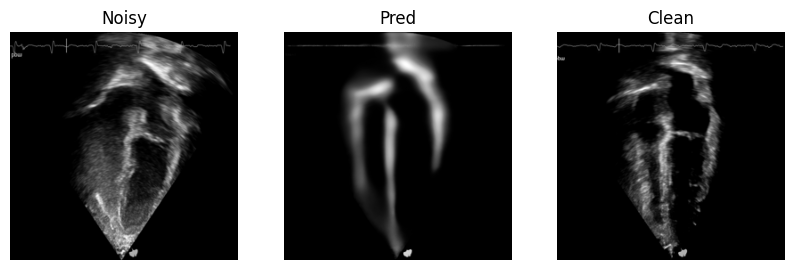

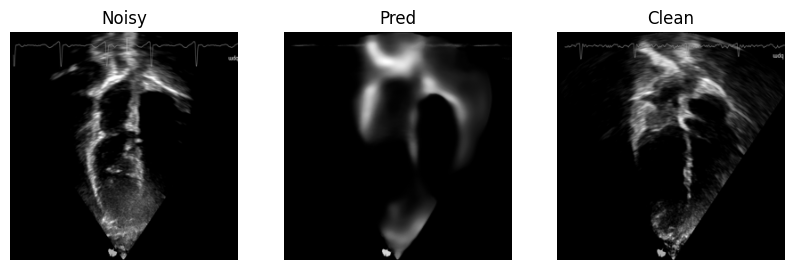

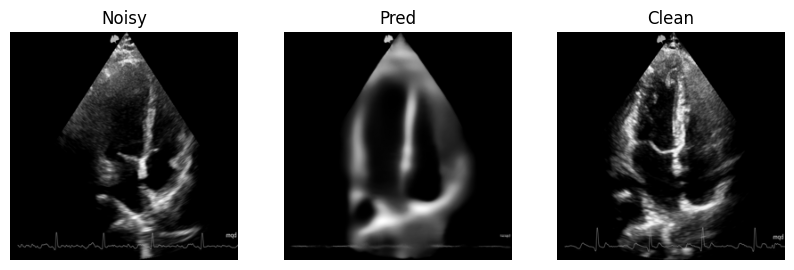

In [18]:
# Visualize a sample prediction from validation set (if trained)
@torch.no_grad()
def show_val_samples(model, loader, n=3):
    model.eval()
    cnt = 0
    for noisy, clean in loader:
        noisy = noisy.to(device)
        clean = clean.to(device)
        pred = model(noisy)
        B = noisy.size(0)
        for i in range(B):
            if cnt >= n:
                return
            fig, axs = plt.subplots(1,3, figsize=(10,3))
            axs[0].imshow(tensor_to_img(noisy[i]), cmap='gray'); axs[0].set_title('Noisy'); axs[0].axis('off')
            axs[1].imshow(tensor_to_img(pred[i]), cmap='gray'); axs[1].set_title('Pred'); axs[1].axis('off')
            axs[2].imshow(tensor_to_img(clean[i]), cmap='gray'); axs[2].set_title('Clean'); axs[2].axis('off')
            plt.show()
            cnt += 1

if 'best_path' in globals() and os.path.isfile(best_ckpt):
    mdl = load_checkpoint(best_ckpt)
    show_val_samples(mdl, val_loader, n=3)
else:
    print('Train and create a best checkpoint to visualize predictions.')